# Study 9: GP Parameter Inference via pyVBMC

Uses pyVBMC (Variational Bayesian Monte Carlo) to infer the posterior over GP parameters
`(length_scale, mu_0)` given participant prevalence ratings — replacing the coarse grid search
in `model-study9-param.ipynb` with principled Bayesian inference.

## What pyVBMC does
pyVBMC approximates the posterior `P(θ | ratings)` where `θ = (length_scale, mu_0)` using
a Gaussian mixture variational approximation. It is designed for expensive, noisy black-box
log-likelihoods — exactly our case, where each evaluation requires running MCMC.

## The objective
For each candidate `θ = (length_scale, mu_0)`, the log joint is:
```
log P(ratings, θ) = log P(ratings | θ) + log P(θ)
```
where `log P(ratings | θ)` is the Option 3 Monte Carlo log likelihood (logsumexp over
thinned MCMC samples), and `log P(θ)` is a broad log-normal prior on length_scale and
a Gaussian prior on mu_0.

## Parameter space
pyVBMC works in an **unconstrained** space. We transform:
- `length_scale > 0` → `log_ls = log(length_scale)` (unconstrained)
- `mu_0 ∈ ℝ` → already unconstrained

So the 2D unconstrained parameter vector is `φ = (log_ls, mu_0)`.

In [8]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"  # Metal incompatible with blackjax

import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
from pyvbmc import VBMC

from model_jax import (
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
    beta_mixture_log_likelihood,
)

print(f"backend: {jax.default_backend()}")

backend: cpu


In [9]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [10]:
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS = list(CSV_TO_FEATURE.keys())
feat_idx = df.set_index('feature')

train_df = df[df.split == 'train']
x_train  = jnp.array(train_df[['x_2d', 'y_2d']].values)
u_train  = jnp.zeros(len(train_df), dtype=jnp.int32)

test_feature_names = [CSV_TO_FEATURE[c] for c in TEST_CSV_COLS]
x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)

col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]
ratings = []
for row in data_rows:
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        ratings.append(vals)
    except (ValueError, IndexError):
        pass
responses = jnp.array(ratings)  # (N, J)
N, J = responses.shape

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}, responses: {responses.shape}")

x_train: (45, 2), x_test: (15, 2), responses: (402, 15)


In [16]:
FIXED_PARAMS = {
    'output_scale': 1.5,
    'beta':         3.0,
}

# MCMC settings — kept lighter than grid search since pyVBMC calls this ~50-100 times
N_WARMUP  = 300
N_SAMPLES = 1500
STEP      = 5    # thinning: 999 → ~200 samples for Option 3

In [17]:
eval_count = [0]  # mutable counter for tracking evaluations
eval_log   = []   # [(phi, log_joint_val, noise_std), ...] for recovery

def log_joint(phi):
    """
    Log joint P(ratings, θ) for pyVBMC.

    phi: 1D array [log_ls, mu_0]  (unconstrained)
    Returns: (log_joint_val, noise_std) — tuple required by specify_target_noise=True
    The noise_std is the std of log_liks_s across MC samples. The linking-function
    shapes are fit ONCE per eval (on the posterior-mean pz1), so this reflects only
    residual y' variation — not the per-draw beta-refitting that previously inflated
    it and biased the inference toward small length_scale.
    """
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    length_scale = float(np.exp(log_ls))

    eval_count[0] += 1
    print(f"  eval {eval_count[0]:3d}: ls={length_scale:.3f}  mu_0={mu_0:.3f}", end="  ")

    # --- log prior ---
    # length_scale: log-normal with median 0.5, broad sigma=1.5 in log space
    log_prior_ls  = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    # mu_0: Gaussian(0, 1)
    log_prior_mu0 = float(-0.5 * mu_0 ** 2)
    log_prior = log_prior_ls + log_prior_mu0

    # --- log likelihood via MCMC ---
    params = {**FIXED_PARAMS, 'length_scale': length_scale, 'mu_0': mu_0}
    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(x_train.shape[0]),
        'test_coherences':     jnp.zeros(J),
    }

    rng_key = jax.random.PRNGKey(0)
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=N_WARMUP)

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, N_SAMPLES)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)  # (S_full, J)

    # --- thin and convert to mixture weights ---
    pz1_draws = np.array(jax.nn.sigmoid(test_coherences_all[::STEP]))  # (S, J)

    # --- linking function: fit Beta-mixture shapes ONCE on the posterior-mean pz1 ---
    # The weight pz1_s still varies per draw at scoring time below (that IS the y'
    # dependence / the marginalization over latent coherences). Only the shape params
    # are frozen, removing the per-draw refitting that inflated noise_std.
    pz1_bar     = jnp.array(pz1_draws.mean(axis=0))                    # (J,) mean P(z=1)
    beta_params = fit_beta_mixtures_all_features(responses, jnp.tile(pz1_bar, (N, 1)))

    # --- score every thinned draw under the same fixed shapes ---
    log_liks_s = [
        float(beta_mixture_log_likelihood(responses, jnp.array(pz1_draws[s]), beta_params))
        for s in range(pz1_draws.shape[0])
    ]

    log_lik   = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
    noise_std = float(np.std(log_liks_s))  # MC noise estimate for pyVBMC

    if not np.isfinite(log_lik):
        print(f"  [WARNING: log_lik={log_lik} is non-finite, clamping to -1e6]")
        log_lik   = -1e6
        noise_std = 1.0

    log_joint_val = float(log_lik + log_prior)
    print(f"log_lik={log_lik:.1f}  noise_std={noise_std:.2f}  log_joint={log_joint_val:.1f}")
    eval_log.append((np.array(phi, dtype=float), log_joint_val, noise_std))
    return log_joint_val, noise_std

In [18]:
# Diagnostic: ls=0.5, mu_0=-1.0 — the outlier cell in the grid search heatmap
# Check variance in log_liks_s and inspect fitted beta params for outlier vs typical samples

diag_ls, diag_mu0 = 0.5, -1.0
print(f"=== Diagnostic: ls={diag_ls}, mu_0={diag_mu0} ===")

params_diag = {**FIXED_PARAMS, 'length_scale': float(diag_ls), 'mu_0': float(diag_mu0)}
log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params_diag)

init_position = {
    'training_coherences': jnp.zeros(x_train.shape[0]),
    'test_coherences':     jnp.zeros(J),
}

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key = jax.random.split(rng_key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
(state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=N_WARMUP)

nuts = blackjax.nuts(log_density_fn, **nuts_params)

@jax.jit
def one_step(state, key):
    return nuts.step(key, state)

keys = jax.random.split(rng_key, N_SAMPLES)
test_coherences_all = []
for key in keys[:-1]:
    state, _ = one_step(state, key)
    test_coherences_all.append(np.array(state.position['test_coherences']))
test_coherences_all = np.array(test_coherences_all)

print(f"test_coherences range: [{test_coherences_all.min():.3f}, {test_coherences_all.max():.3f}]")

log_liks_s        = []
pz1_all_s         = []
beta_params_all_s = []
for s in range(0, test_coherences_all.shape[0], STEP):
    pz1_s         = jnp.array(jax.nn.sigmoid(test_coherences_all[s]))
    pz1_s_bc      = jnp.tile(pz1_s, (N, 1))
    beta_params_s = fit_beta_mixtures_all_features(responses, pz1_s_bc)
    ll_s          = float(beta_mixture_log_likelihood(responses, pz1_s, beta_params_s))
    log_liks_s.append(ll_s)
    pz1_all_s.append(np.array(pz1_s))
    beta_params_all_s.append(np.array(beta_params_s))

log_liks_s        = np.array(log_liks_s)
pz1_all_s         = np.array(pz1_all_s)          # (n_thinned, J)
beta_params_all_s = np.array(beta_params_all_s)  # (n_thinned, J, 4)

print(f"\nlog_liks_s across {len(log_liks_s)} samples:")
print(f"  mean={log_liks_s.mean():.1f}  std={log_liks_s.std():.1f}")
print(f"  min={log_liks_s.min():.1f}  max={log_liks_s.max():.1f}")

top5_idx   = np.argsort(log_liks_s)[-5:][::-1]
median_idx = np.argsort(log_liks_s)[len(log_liks_s)//2]

print(f"\npz1 and beta params for outlier vs typical samples:")
for idx in list(top5_idx[:2]) + [median_idx]:
    label = 'OUTLIER' if idx in top5_idx[:2] else 'median'
    pz1 = pz1_all_s[idx]
    bp  = beta_params_all_s[idx]  # (J, 4): alpha_kl, beta_kl, alpha_nkl, beta_nkl
    print(f"\n  [{label}] ll_s={log_liks_s[idx]:.1f}  pz1=[{pz1.min():.3f}, {pz1.max():.3f}]  "
          f"beta_params=[{bp.min():.3f}, {bp.max():.3f}]")
    print(f"  {'feature':<30} {'pz1':>6}  {'a_kl':>7} {'b_kl':>7} {'a_nkl':>7} {'b_nkl':>7}")
    for j in range(J):
        print(f"  {test_feature_names[j]:<30} {pz1[j]:>6.3f}  "
              f"{bp[j,0]:>7.3f} {bp[j,1]:>7.3f} {bp[j,2]:>7.3f} {bp[j,3]:>7.3f}")

log_lik_logsumexp = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
log_lik_median    = float(np.median(log_liks_s))
print(f"\nFinal log_lik (logsumexp): {log_lik_logsumexp:.1f}")
print(f"Final log_lik (median):    {log_lik_median:.1f}")

=== Diagnostic: ls=0.5, mu_0=-1.0 ===
test_coherences range: [-1.372, 3.934]

log_liks_s across 300 samples:
  mean=-27079.0  std=432.5
  min=-29015.6  max=-26588.6

pz1 and beta params for outlier vs typical samples:

  [OUTLIER] ll_s=-26588.6  pz1=[0.880, 0.968]  beta_params=[0.418, 3269017.500]
  feature                           pz1     a_kl    b_kl   a_nkl   b_nkl
  can eat spicy food              0.891    0.947   0.502 24813.934 24884.316
  eat breakfast very late         0.903    0.813   0.787 5310.809 16077.865
  eat five meals a day            0.886    0.729   0.499   4.122  20.242
  like juice with pulp            0.901    0.919   0.524 17512.061 17475.525
  put pepper on all their foods   0.880    0.697   0.557   2.786   5.147
  cry easily                      0.944    0.946   0.765   5.674   9.257
  like to collect rocks           0.898    0.720   0.543   8.304  42.661
  like to dance                   0.947    1.730   0.508 3269017.500 3269017.500
  like to give high-fives

## pyVBMC setup

pyVBMC takes in:
- `x0`: starting point in unconstrained space `[log_ls, mu_0]`
- `lb`, `ub`: hard bounds (log_ls in ~[-3, 3] → ls in [0.05, 20]; mu_0 in [-3, 3])
- `plb`, `pub`: plausible bounds (where most of the posterior mass is expected)

Starting from `(ls=0.4, mu_0=0.0)` which was near the grid search best.

In [19]:
# --- Fix a pyVBMC bug exposed under newer numpy ---
# In _gp_log_joint, the "Drop extra dims if Ns == 1" cleanup squeezes G but NOT varG,
# so with a single GP hyperparameter sample varG stays a shape-(1,) array. It becomes
# varF, and then `elbo_stats["varF"][idx] = varF` raises "setting an array element with
# a sequence". Squeeze varG (return index 2) to a scalar — exactly what pyVBMC already
# does for G. (The skip_elbo_variance option does NOT work: its compute_var=False path
# returns an unbound J_sjk.) Idempotent so re-running this cell won't double-wrap.
import pyvbmc.vbmc.variational_optimization as _vopt
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig_gp_log_joint = _vopt._gp_log_joint
    def _gp_log_joint_scalar_varg(*args, **kwargs):
        out = list(_orig_gp_log_joint(*args, **kwargs))
        if out[2] is not None:          # varG -> scalar
            out[2] = float(np.squeeze(out[2]))
        return tuple(out)
    _gp_log_joint_scalar_varg._varg_squeeze_patch = True
    _vopt._gp_log_joint = _gp_log_joint_scalar_varg
    print("patched _gp_log_joint (varG squeeze)")

# Starting point: ls=0.4, mu_0=0.0
x0  = np.array([np.log(0.4), 0.0])

# Hard bounds
lb  = np.array([np.log(0.05), -4.0])  # ls >= 0.05, mu_0 >= -4
ub  = np.array([np.log(20.0),  4.0])  # ls <= 20,   mu_0 <= 4

# Plausible bounds (where we expect most posterior mass based on grid search)
plb = np.array([np.log(0.1), -2.0])
pub = np.array([np.log(5.0),  2.0])

print(f"Starting point: log_ls={x0[0]:.2f} (ls={np.exp(x0[0]):.2f}), mu_0={x0[1]:.2f}")
print(f"Bounds: ls in [{np.exp(lb[0]):.2f}, {np.exp(ub[0]):.2f}], mu_0 in [{lb[1]}, {ub[1]}]")
print()

# specify_target_noise=True: log_joint returns (value, noise_std) tuple,
# activating pyVBMC's uncertainty handling (level 2).
vbmc = VBMC(log_joint, x0, lb, ub, plb, pub,
            options={'specify_target_noise': True})
vbmc_result, vbmc_stats = vbmc.optimize()

patched _gp_log_joint (varG squeeze)
Starting point: log_ls=-0.92 (ls=0.40), mu_0=0.00
Bounds: ls in [0.05, 20.00], mu_0 in [-4.0, 4.0]

Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=0.400  mu_0=0.000  log_lik=-26760.7  noise_std=181.53  log_joint=-26760.7
  eval   2: ls=2.248  mu_0=1.597  log_lik=-26874.6  noise_std=189.43  log_joint=-26876.4
  eval   3: ls=4.704  mu_0=1.748  log_lik=-27122.3  noise_std=263.27  log_joint=-27125.0
  eval   4: ls=4.269  mu_0=0.101  log_lik=-26827.3  noise_std=110.29  log_joint=-26828.4
  eval   5: ls=0.101  mu_0=0.374  log_lik=-26723.4  noise_std=100.83  log_joint=-26724.0
  eval   6: ls=0.799  mu_0=-0.166  log_lik=-26889.8  noise_std=1

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar subtract
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar multiply
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),


  eval  58: ls=0.050  mu_0=-0.011  log_lik=-26644.1  noise_std=123.19  log_joint=-26645.2
  eval  59: ls=0.234  mu_0=-3.736  log_lik=-26689.3  noise_std=94.30  log_joint=-26696.4
  eval  60: ls=0.050  mu_0=-3.343  log_lik=-26549.7  noise_std=481.35  log_joint=-26556.4
    10         60      -26633.09        26.65       640.23        2   1.51e+04     
  eval  61: ls=0.721  mu_0=-3.944  log_lik=-26779.4  noise_std=81.96  log_joint=-26787.2
  eval  62: ls=0.053  mu_0=-3.943  log_lik=-26704.7  noise_std=562.17  log_joint=-26713.6
  eval  63: ls=0.053  mu_0=-3.996  log_lik=-26675.4  noise_std=530.40  log_joint=-26684.5
  eval  64: ls=0.053  mu_0=-4.000  log_lik=-26644.9  noise_std=551.64  log_joint=-26654.0
  eval  65: ls=0.050  mu_0=-1.912  log_lik=-26605.9  noise_std=130.84  log_joint=-26608.9
    11         65      -26610.98        22.47        46.58        2   1.11e+03     
  eval  66: ls=0.050  mu_0=-1.902  log_lik=-26619.4  noise_std=112.65  log_joint=-26622.3
  eval  67: ls=0.050  mu

In [20]:
import numpy as np

# --- 1. Your own evaluation log: the cleanest, most trustworthy record ---
phis       = np.array([e[0] for e in eval_log])      # (n_eval, 2) = [log_ls, mu_0]
log_joints = np.array([e[1] for e in eval_log])
noise_stds = np.array([e[2] for e in eval_log])
ls_evals   = np.exp(phis[:, 0])
mu0_evals  = phis[:, 1]
print(f"{len(eval_log)} evaluations recovered from eval_log")

best = int(np.argmax(log_joints))
print(f"best eval: ls={ls_evals[best]:.3f}  mu_0={mu0_evals[best]:.3f}  "
      f"log_joint={log_joints[best]:.1f}  noise_std={noise_stds[best]:.1f}")

# --- 2. The variational posterior VBMC had built up to the crash ---
# vbmc.vp = last completed iteration's posterior (not reassigned during the failed step)
try:
    phi_s, _ = vbmc.vp.sample(int(1e4))
    print(f"\nrecovered vp: posterior mean ls={np.exp(phi_s[:,0]).mean():.3f}  "
          f"mu_0={phi_s[:,1].mean():.3f}  (K={vbmc.vp.K} components)")
    ls_post, mu0_post = np.exp(phi_s[:, 0]), phi_s[:, 1]
except Exception as err:
    print(f"\nvp.sample failed ({err}); rely on eval_log + GP surrogate instead")

# --- 3. (optional) all completed iterations' posteriors, if you want history ---
vp_hist = vbmc.iteration_history.get("vp")
print(f"\n{0 if vp_hist is None else len(vp_hist)} completed iterations stored "
      f"in iteration_history['vp']")

300 evaluations recovered from eval_log
best eval: ls=0.050  mu_0=-4.000  log_joint=-26451.8  noise_std=188.2

recovered vp: posterior mean ls=0.056  mu_0=-3.993  (K=50 components)

59 completed iterations stored in iteration_history['vp']


In [23]:
# Extract posterior samples from the variational approximation
# vbmc.optimize() returns (vp, results), so vbmc_result IS the VariationalPosterior.
phi_samples, log_weights = vbmc_result.sample(int(1e4))
# phi_samples: (10000, 2) in unconstrained space [log_ls, mu_0]

ls_samples  = np.exp(phi_samples[:, 0])  # back-transform to length_scale
mu0_samples = phi_samples[:, 1]

print(f"Posterior mean:   ls={ls_samples.mean():.3f}  mu_0={mu0_samples.mean():.3f}")
print(f"Posterior median: ls={np.median(ls_samples):.3f}  mu_0={np.median(mu0_samples):.3f}")
print(f"Posterior std:    ls={ls_samples.std():.3f}  mu_0={mu0_samples.std():.3f}")
print(f"95% CI ls:  [{np.percentile(ls_samples, 2.5):.3f}, {np.percentile(ls_samples, 97.5):.3f}]")
print(f"95% CI mu_0: [{np.percentile(mu0_samples, 2.5):.3f}, {np.percentile(mu0_samples, 97.5):.3f}]")

Posterior mean:   ls=0.056  mu_0=-3.993
Posterior median: ls=0.054  mu_0=-4.000
Posterior std:    ls=0.009  mu_0=0.051
95% CI ls:  [0.050, 0.081]
95% CI mu_0: [-4.000, -3.947]


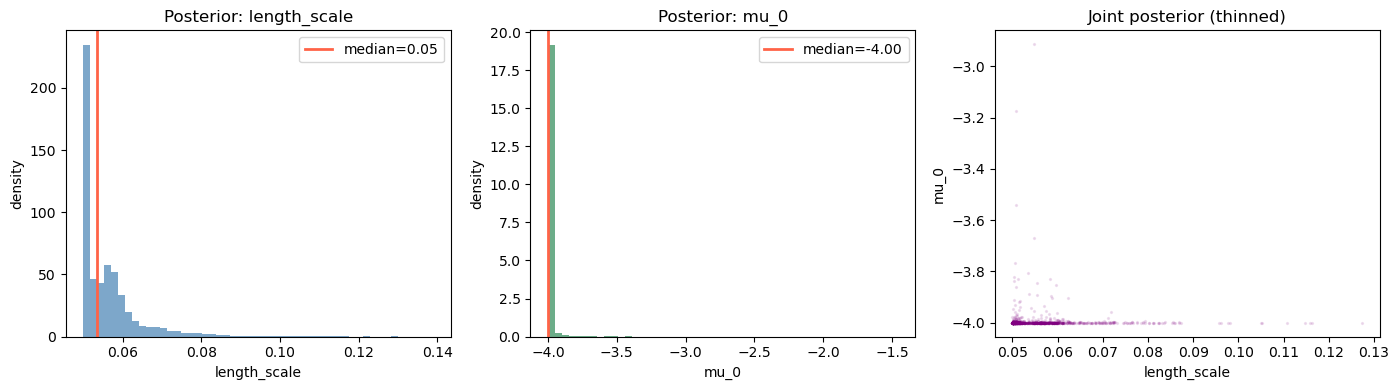

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Marginal: length_scale
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(np.median(ls_samples), color='tomato', lw=2, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale')
axes[0].set_ylabel('density')
axes[0].set_title('Posterior: length_scale')
axes[0].legend()

# Marginal: mu_0
axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(np.median(mu0_samples), color='tomato', lw=2, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0')
axes[1].set_ylabel('density')
axes[1].set_title('Posterior: mu_0')
axes[1].legend()

# Joint posterior
axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].set_xlabel('length_scale')
axes[2].set_ylabel('mu_0')
axes[2].set_title('Joint posterior (thinned)')

plt.tight_layout()
plt.show()

Running forward pass at posterior mean: ls=0.056, mu_0=-3.993
log_lik=-26849.6  Pearson r=0.987 (reference only)


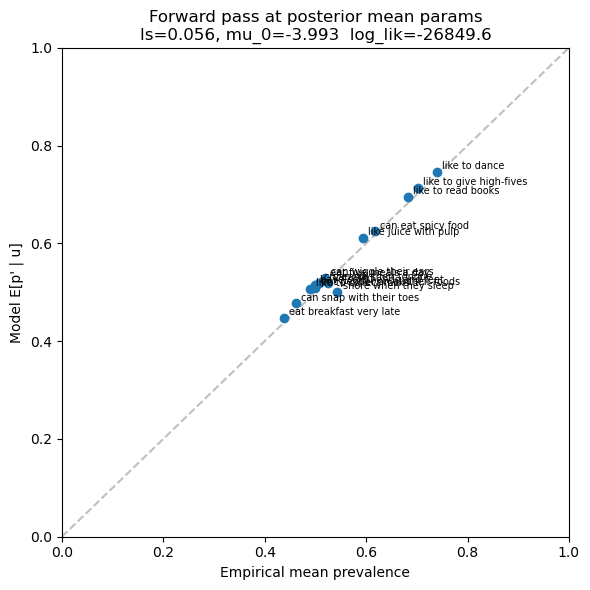

In [25]:
# Forward pass at posterior mean params
ls_mean  = float(ls_samples.mean())
mu0_mean = float(mu0_samples.mean())
print(f"Running forward pass at posterior mean: ls={ls_mean:.3f}, mu_0={mu0_mean:.3f}")

params_best = {**FIXED_PARAMS, 'length_scale': ls_mean, 'mu_0': mu0_mean}
log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params_best)

init_position = {
    'training_coherences': jnp.zeros(x_train.shape[0]),
    'test_coherences':     jnp.zeros(J),
}

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key = jax.random.split(rng_key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
(state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=500)

nuts = blackjax.nuts(log_density_fn, **nuts_params)

@jax.jit
def one_step(state, key):
    return nuts.step(key, state)

keys = jax.random.split(rng_key, 2000)
test_coherences_all = []
for key in keys[:-1]:
    state, _ = one_step(state, key)
    test_coherences_all.append(np.array(state.position['test_coherences']))
test_coherences_all = np.array(test_coherences_all)  # (S, J)

# Thin to mixture weights; fit the linking function ONCE on the posterior-mean pz1
# (matches log_joint: shapes fixed across draws, only the weight pz1_s varies).
pz1_draws = np.array(jax.nn.sigmoid(test_coherences_all[::10]))  # (S, J)
pz1_test  = pz1_draws.mean(axis=0)                               # (J,) mean P(z=1)
beta_params = fit_beta_mixtures_all_features(responses, jnp.tile(jnp.array(pz1_test), (N, 1)))
a_kl  = np.array(beta_params[:, 0]); b_kl  = np.array(beta_params[:, 1])
a_nkl = np.array(beta_params[:, 2]); b_nkl = np.array(beta_params[:, 3])
mean_kl  = a_kl  / (a_kl  + b_kl)
mean_nkl = a_nkl / (a_nkl + b_nkl)

# Predicted prevalence E[p'|u] under the fixed linking function, averaged over draws,
# and the Option 3 log likelihood scored with those same fixed shapes.
pred_prevalences_s = [
    pz1_draws[s] * mean_kl + (1 - pz1_draws[s]) * mean_nkl
    for s in range(pz1_draws.shape[0])
]
log_liks_s = [
    beta_mixture_log_likelihood(responses, jnp.array(pz1_draws[s]), beta_params)
    for s in range(pz1_draws.shape[0])
]

pred_prevalence = np.mean(pred_prevalences_s, axis=0)
log_lik_best = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))

empirical_mean = np.array(responses.mean(axis=0))
corr = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
print(f"log_lik={log_lik_best:.1f}  Pearson r={corr:.3f} (reference only)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(empirical_mean, pred_prevalence, zorder=3)
for j, name in enumerate(test_feature_names):
    ax.annotate(name, (empirical_mean[j], pred_prevalence[j]),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
lims = [0, 1]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Empirical mean prevalence')
ax.set_ylabel("Model E[p' | u]")
ax.set_title(f'Forward pass at posterior mean params\nls={ls_mean:.3f}, mu_0={mu0_mean:.3f}  log_lik={log_lik_best:.1f}')
plt.tight_layout()
plt.show()

Running forward pass at posterior mean: ls=10.000, mu_0=-3.993
log_lik=-26824.7  Pearson r=0.770 (reference only)


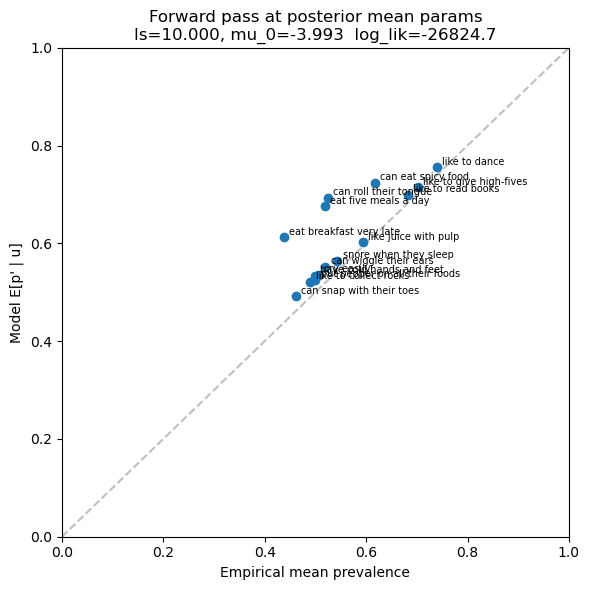

In [26]:
# Forward pass at posterior mean params
ls_mean  = float(10)
mu0_mean = float(mu0_samples.mean())
print(f"Running forward pass at posterior mean: ls={ls_mean:.3f}, mu_0={mu0_mean:.3f}")

params_best = {**FIXED_PARAMS, 'length_scale': ls_mean, 'mu_0': mu0_mean}
log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params_best)

init_position = {
    'training_coherences': jnp.zeros(x_train.shape[0]),
    'test_coherences':     jnp.zeros(J),
}

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key = jax.random.split(rng_key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
(state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=500)

nuts = blackjax.nuts(log_density_fn, **nuts_params)

@jax.jit
def one_step(state, key):
    return nuts.step(key, state)

keys = jax.random.split(rng_key, 2000)
test_coherences_all = []
for key in keys[:-1]:
    state, _ = one_step(state, key)
    test_coherences_all.append(np.array(state.position['test_coherences']))
test_coherences_all = np.array(test_coherences_all)  # (S, J)

# Thin to mixture weights; fit the linking function ONCE on the posterior-mean pz1
# (matches log_joint: shapes fixed across draws, only the weight pz1_s varies).
pz1_draws = np.array(jax.nn.sigmoid(test_coherences_all[::10]))  # (S, J)
pz1_test  = pz1_draws.mean(axis=0)                               # (J,) mean P(z=1)
beta_params = fit_beta_mixtures_all_features(responses, jnp.tile(jnp.array(pz1_test), (N, 1)))
a_kl  = np.array(beta_params[:, 0]); b_kl  = np.array(beta_params[:, 1])
a_nkl = np.array(beta_params[:, 2]); b_nkl = np.array(beta_params[:, 3])
mean_kl  = a_kl  / (a_kl  + b_kl)
mean_nkl = a_nkl / (a_nkl + b_nkl)

# Predicted prevalence E[p'|u] under the fixed linking function, averaged over draws,
# and the Option 3 log likelihood scored with those same fixed shapes.
pred_prevalences_s = [
    pz1_draws[s] * mean_kl + (1 - pz1_draws[s]) * mean_nkl
    for s in range(pz1_draws.shape[0])
]
log_liks_s = [
    beta_mixture_log_likelihood(responses, jnp.array(pz1_draws[s]), beta_params)
    for s in range(pz1_draws.shape[0])
]

pred_prevalence = np.mean(pred_prevalences_s, axis=0)
log_lik_best = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))

empirical_mean = np.array(responses.mean(axis=0))
corr = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
print(f"log_lik={log_lik_best:.1f}  Pearson r={corr:.3f} (reference only)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(empirical_mean, pred_prevalence, zorder=3)
for j, name in enumerate(test_feature_names):
    ax.annotate(name, (empirical_mean[j], pred_prevalence[j]),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
lims = [0, 1]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Empirical mean prevalence')
ax.set_ylabel("Model E[p' | u]")
ax.set_title(f'Forward pass at posterior mean params\nls={ls_mean:.3f}, mu_0={mu0_mean:.3f}  log_lik={log_lik_best:.1f}')
plt.tight_layout()
plt.show()

Running forward pass at posterior mean: ls=1.000, mu_0=-3.993
log_lik=-26714.9  Pearson r=0.914 (reference only)


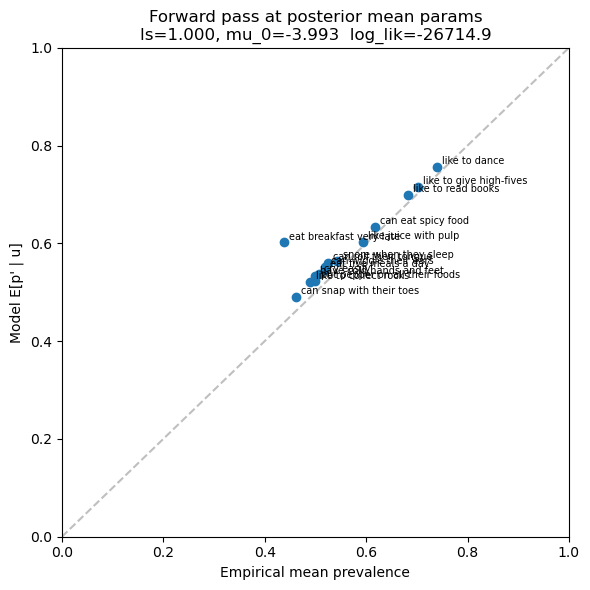

In [28]:
# Forward pass at posterior mean params
ls_mean  = float(1)
mu0_mean = float(mu0_samples.mean())
print(f"Running forward pass at posterior mean: ls={ls_mean:.3f}, mu_0={mu0_mean:.3f}")

params_best = {**FIXED_PARAMS, 'length_scale': ls_mean, 'mu_0': mu0_mean}
log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params_best)

init_position = {
    'training_coherences': jnp.zeros(x_train.shape[0]),
    'test_coherences':     jnp.zeros(J),
}

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key = jax.random.split(rng_key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
(state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=500)

nuts = blackjax.nuts(log_density_fn, **nuts_params)

@jax.jit
def one_step(state, key):
    return nuts.step(key, state)

keys = jax.random.split(rng_key, 2000)
test_coherences_all = []
for key in keys[:-1]:
    state, _ = one_step(state, key)
    test_coherences_all.append(np.array(state.position['test_coherences']))
test_coherences_all = np.array(test_coherences_all)  # (S, J)

# Thin to mixture weights; fit the linking function ONCE on the posterior-mean pz1
# (matches log_joint: shapes fixed across draws, only the weight pz1_s varies).
pz1_draws = np.array(jax.nn.sigmoid(test_coherences_all[::10]))  # (S, J)
pz1_test  = pz1_draws.mean(axis=0)                               # (J,) mean P(z=1)
beta_params = fit_beta_mixtures_all_features(responses, jnp.tile(jnp.array(pz1_test), (N, 1)))
a_kl  = np.array(beta_params[:, 0]); b_kl  = np.array(beta_params[:, 1])
a_nkl = np.array(beta_params[:, 2]); b_nkl = np.array(beta_params[:, 3])
mean_kl  = a_kl  / (a_kl  + b_kl)
mean_nkl = a_nkl / (a_nkl + b_nkl)

# Predicted prevalence E[p'|u] under the fixed linking function, averaged over draws,
# and the Option 3 log likelihood scored with those same fixed shapes.
pred_prevalences_s = [
    pz1_draws[s] * mean_kl + (1 - pz1_draws[s]) * mean_nkl
    for s in range(pz1_draws.shape[0])
]
log_liks_s = [
    beta_mixture_log_likelihood(responses, jnp.array(pz1_draws[s]), beta_params)
    for s in range(pz1_draws.shape[0])
]

pred_prevalence = np.mean(pred_prevalences_s, axis=0)
log_lik_best = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))

empirical_mean = np.array(responses.mean(axis=0))
corr = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
print(f"log_lik={log_lik_best:.1f}  Pearson r={corr:.3f} (reference only)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(empirical_mean, pred_prevalence, zorder=3)
for j, name in enumerate(test_feature_names):
    ax.annotate(name, (empirical_mean[j], pred_prevalence[j]),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
lims = [0, 1]
ax.plot(lims, lims, '--', color='gray', alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Empirical mean prevalence')
ax.set_ylabel("Model E[p' | u]")
ax.set_title(f'Forward pass at posterior mean params\nls={ls_mean:.3f}, mu_0={mu0_mean:.3f}  log_lik={log_lik_best:.1f}')
plt.tight_layout()
plt.show()

In [29]:
# === ELBO model comparison ===
# VBMC's ELBO estimates the log marginal likelihood log P(ratings | model) = log ∫ P(ratings|θ)P(θ)dθ.
# Differences in ELBO between models are log Bayes factors — the right metric for "does fitting
# the length scale help?", unlike the forward-pass log_lik (data fit at a point), which favors
# the more flexible / smaller-ls model regardless of whether the flexibility is warranted.
#
# IMPORTANT: an ELBO comes only from a full VBMC run, not a forward pass. The fixed-ls forward
# passes above report log_lik, which is NOT comparable across ls. To get a null-model ELBO,
# run VBMC with the length scale fixed (e.g. set a fixed large ls and optimize only mu_0 — a
# separate 1D VBMC run), then re-run this cell with a new MODEL_LABEL. The registry persists,
# so registered models accumulate and get compared.

MODEL_LABEL = "free (ls, mu_0)"

elbo_results = globals().get("elbo_results", {})
elbo_results[MODEL_LABEL] = {
    "elbo":       float(vbmc_stats["elbo"]),
    "elbo_sd":    float(vbmc_stats["elbo_sd"]),
    "converged":  vbmc_stats["convergence_status"],
    "func_count": int(vbmc_stats["func_count"]),
}

print("Registered ELBOs (log marginal likelihood estimates; higher = better):")
print(f"  {'model':<22} {'ELBO':>12} {'± SD':>7}  {'converged':>10} {'evals':>6}")
for name, r in elbo_results.items():
    print(f"  {name:<22} {r['elbo']:>12.1f} {r['elbo_sd']:>7.2f}  "
          f"{r['converged']:>10} {r['func_count']:>6}")

labels = list(elbo_results.keys())
if len(labels) >= 2:
    print("\nPairwise ELBO differences (Δ = log Bayes factor; + favors the first model):")
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            a, b = labels[i], labels[j]
            d  = elbo_results[a]["elbo"] - elbo_results[b]["elbo"]
            sd = np.hypot(elbo_results[a]["elbo_sd"], elbo_results[b]["elbo_sd"])
            print(f"  {a}  vs  {b}:  ΔELBO = {d:+.1f} ± {sd:.1f}")
else:
    print("\nOnly one model registered. Run VBMC with the length scale fixed (null model),"
          "\nthen re-run this cell with a different MODEL_LABEL to get ΔELBO (log Bayes factor).")

if elbo_results[MODEL_LABEL]["converged"] != "probable":
    print("\n⚠️  convergence_status is not 'probable' — this ELBO is from an unconverged run,"
          "\n   so treat its value (and any comparison) as provisional.")

Registered ELBOs (log marginal likelihood estimates; higher = better):
  model                          ELBO    ± SD   converged  evals
  free (ls, mu_0)            -26595.5   24.23          no    300

Only one model registered. Run VBMC with the length scale fixed (null model),
then re-run this cell with a different MODEL_LABEL to get ΔELBO (log Bayes factor).

⚠️  convergence_status is not 'probable' — this ELBO is from an unconverged run,
   so treat its value (and any comparison) as provisional.
